In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# from optim_funcs import sgd, adam

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
plt.style.use(["science", "bright"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"
plt.rcParams["text.usetex"] = True

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/"

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    "F430M",
    "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

In [3]:
def get_rgb(
    TARGPROP,
    PATT_NUM=1,
    NUMDTHPT=1,
):
    files = sorted(
        file_fn(data_path + "AB-DOR/calslope/"),
        key=lambda hdu: hdu[0].header.get("EXPMID", float("inf")),
    )

    channels = {}
    for file in files:
        if (
            file[0].header["PATT_NUM"] != PATT_NUM
            or file[0].header["NUMDTHPT"] != NUMDTHPT
        ):
            continue
        if file[0].header["TARGPROP"] == TARGPROP:
            for filt in FILTERS:
                if file[0].header["FILTER"] == filt:
                    channels[filt] = file

    return channels


def normalise_rgb(rgb_dict, p=1.0):

    r = np.array(rgb_dict["F480M"]["SLOPE"].data[0])
    g = np.array(rgb_dict["F430M"]["SLOPE"].data[0])
    b = np.array(rgb_dict["F380M"]["SLOPE"].data[0])

    r_badpix = np.array(rgb_dict["F480M"]["BADPIX"].data)
    g_badpix = np.array(rgb_dict["F430M"]["BADPIX"].data)
    b_badpix = np.array(rgb_dict["F380M"]["BADPIX"].data)

    badpix = r_badpix | g_badpix | b_badpix

    r_max = np.nanmax(r)
    g_max = np.nanmax(g)
    b_max = np.nanmax(b)
    maxx = np.nanmax(np.array([r_max, g_max, b_max]))

    r = np.clip(np.where(badpix, 0.0, r), 0.0) / maxx
    g = np.clip(np.where(badpix, 0.0, g), 0.0) / maxx
    b = np.clip(np.where(badpix, 0.0, b), 0.0) / maxx

    return np.stack([r**p, g**p, b**p], axis=-1)  # Shape: (H, W, 3)

# Loading in data

## AB-DOR

In [140]:
files = file_fn(
    data_path + "AB-DOR/calslope/",
    filters=FILTERS,
)

for file in files:
    print(
        file[0].header["TARGPROP"],
        file[0].header["PATT_NUM"],
        file[0].header["NUMDTHPT"],
        file[0].header["ROLL_REF"],
    )

HD-36805 24 25 171.9845972085314
HD-37093 1 1 171.4174575722849
AB-DOR 1 1 171.8225879284531
HD-36805 6 25 171.9845974785219
HD-36805 16 25 171.9845906652887
HD-36805 13 25 171.9845778236424
HD-36805 3 25 171.9846298403079
AB-DOR 1 5 171.8422059293656
AB-DOR 4 5 171.8418574729731
HD-36805 1 1 171.9437711448584
AB-DOR 1 1 171.7649906028679
HD-36805 14 25 171.9845584326484
HD-36805 4 25 171.9845999314871
HD-36805 1 25 171.9851349224217
HD-36805 11 25 171.9845689177595
HD-36805 9 25 171.9845413225357
AB-DOR 1 1 171.8225535580934
HD-36805 8 25 171.9845799022418
HD-36805 19 25 171.9845972909968
AB-DOR 1 1 171.7650837268791
HD-36805 25 25 171.9845985688205
AB-DOR 1 1 171.8225990267101
HD-37093 4 5 171.4573200648865
HD-36805 15 25 171.984582859378
AB-DOR 1 1 171.8225545028919
HD-36805 12 25 171.9845986400763
HD-36805 22 25 171.9845877659538
HD-36805 7 25 171.9846283875455
HD-37093 3 5 171.457373726246
HD-37093 1 1 171.4389892325803
HD-37093 2 5 171.4573747856612
AB-DOR 2 5 171.8422696035983
H

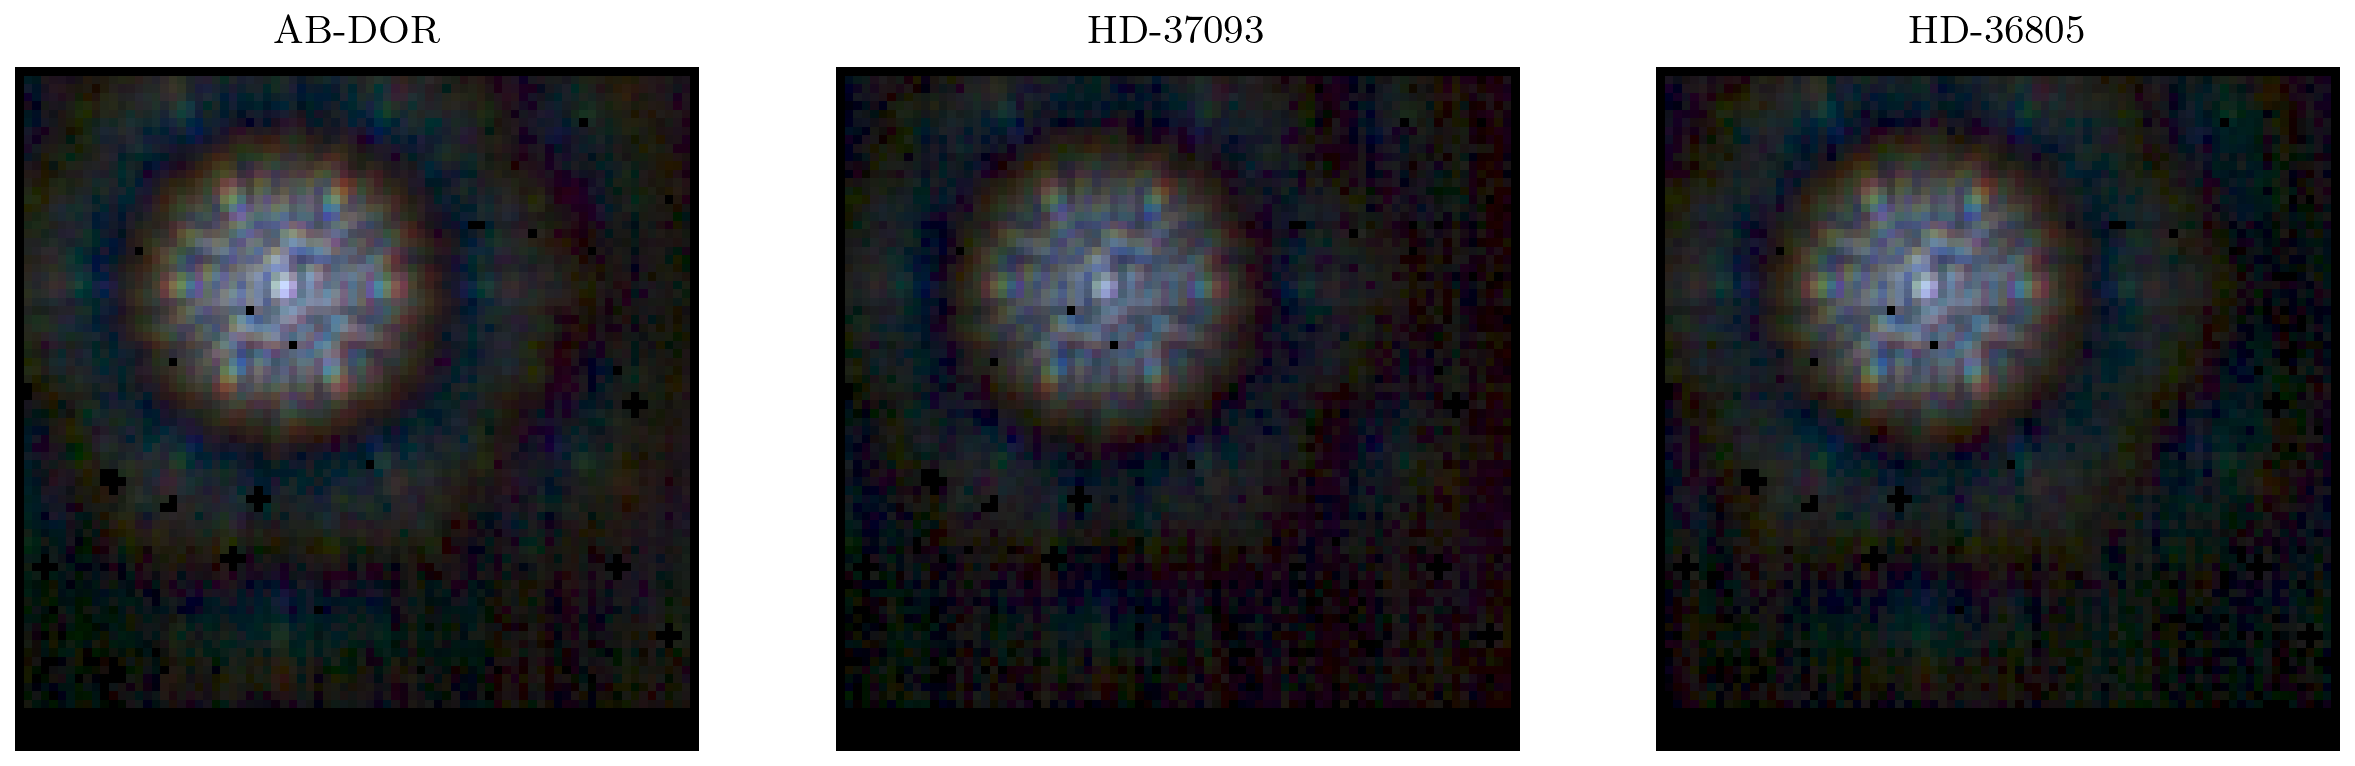

In [5]:
abdor = get_rgb("AB-DOR")
abdorcal1 = get_rgb("HD-37093")
abdorcal2 = get_rgb("HD-36805")


# for filt, ch in abdor.items():
#     # print(ch[0].header)


abdor_rgb = normalise_rgb(abdor, p=0.3)
abdorcal1_rgb = normalise_rgb(abdorcal1, p=0.3)
abdorcal2_rgb = normalise_rgb(abdorcal2, p=0.3)


fig, ax = plt.subplots(1, 3, figsize=(10, 3), dpi=300)

ax[0].imshow(abdor_rgb, origin="lower", interpolation="nearest")
ax[0].set(title="AB-DOR")
ax[0].axis("off")

ax[1].imshow(abdorcal1_rgb, origin="lower", interpolation="nearest")
ax[1].set(title="HD-37093")
ax[1].axis("off")

ax[2].imshow(abdorcal2_rgb, origin="lower", interpolation="nearest")
ax[2].set(title="HD-36805")
ax[2].axis("off")

plt.show()

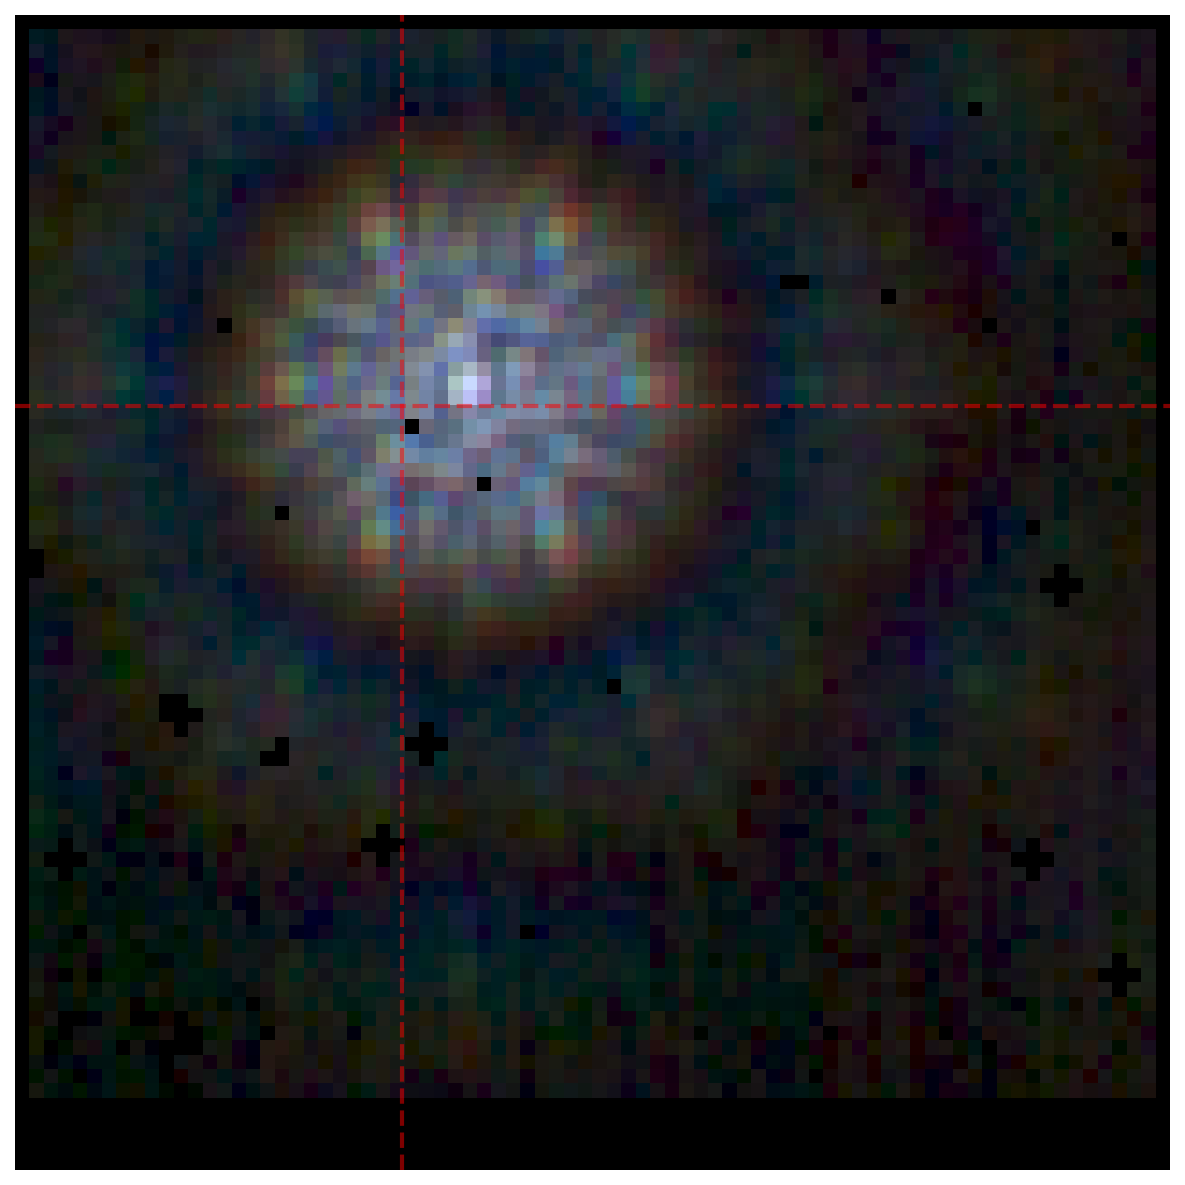

In [ ]:
from dLux import utils as dlu

theta = 171.84  # deg, roll angle from fits header
phi = -79.4  # deg
pscale = 0.065524085  # arcsec/pixel
sep = 325.6e-3 / pscale  # mas

pa = 90 - theta + phi

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(abdor_rgb)
# ax.scatter(46, 41)

ax.axhline(
    54 + sep * np.sin(dlu.deg2rad(pa)),
    color="red",
    linestyle="--",
    alpha=0.5,
)

ax.axvline(31 + sep * np.cos(dlu.deg2rad(pa)), color="red", linestyle="--", alpha=0.5)
ax.axis("off")
plt.show()

In [152]:
file[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
DATE    = '2023-06-26T18:16:04.917' / UTC date file created                     
ORIGIN  = 'STSCI   '           / Organization responsible for creating file     
TIMESYS = 'UTC     '           / principal time system for time-related keywords
TIMEUNIT= 's       '           / Default unit applicable to all time values     
FILENAME= 'jw01093018001_03102_00001_nis_calslope.fits' / Name of the file      
SDP_VER = '2023_1a '           / Data processing software version number        
PRD_VER = 'PRDOPSSOC-061'      / S&OC PRD version number used in data processing
OSS_VER = '008.004.007.000'    / Observatory Scheduling Software (OSS) version n
DATAMODL= 'Level1bModel'    

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


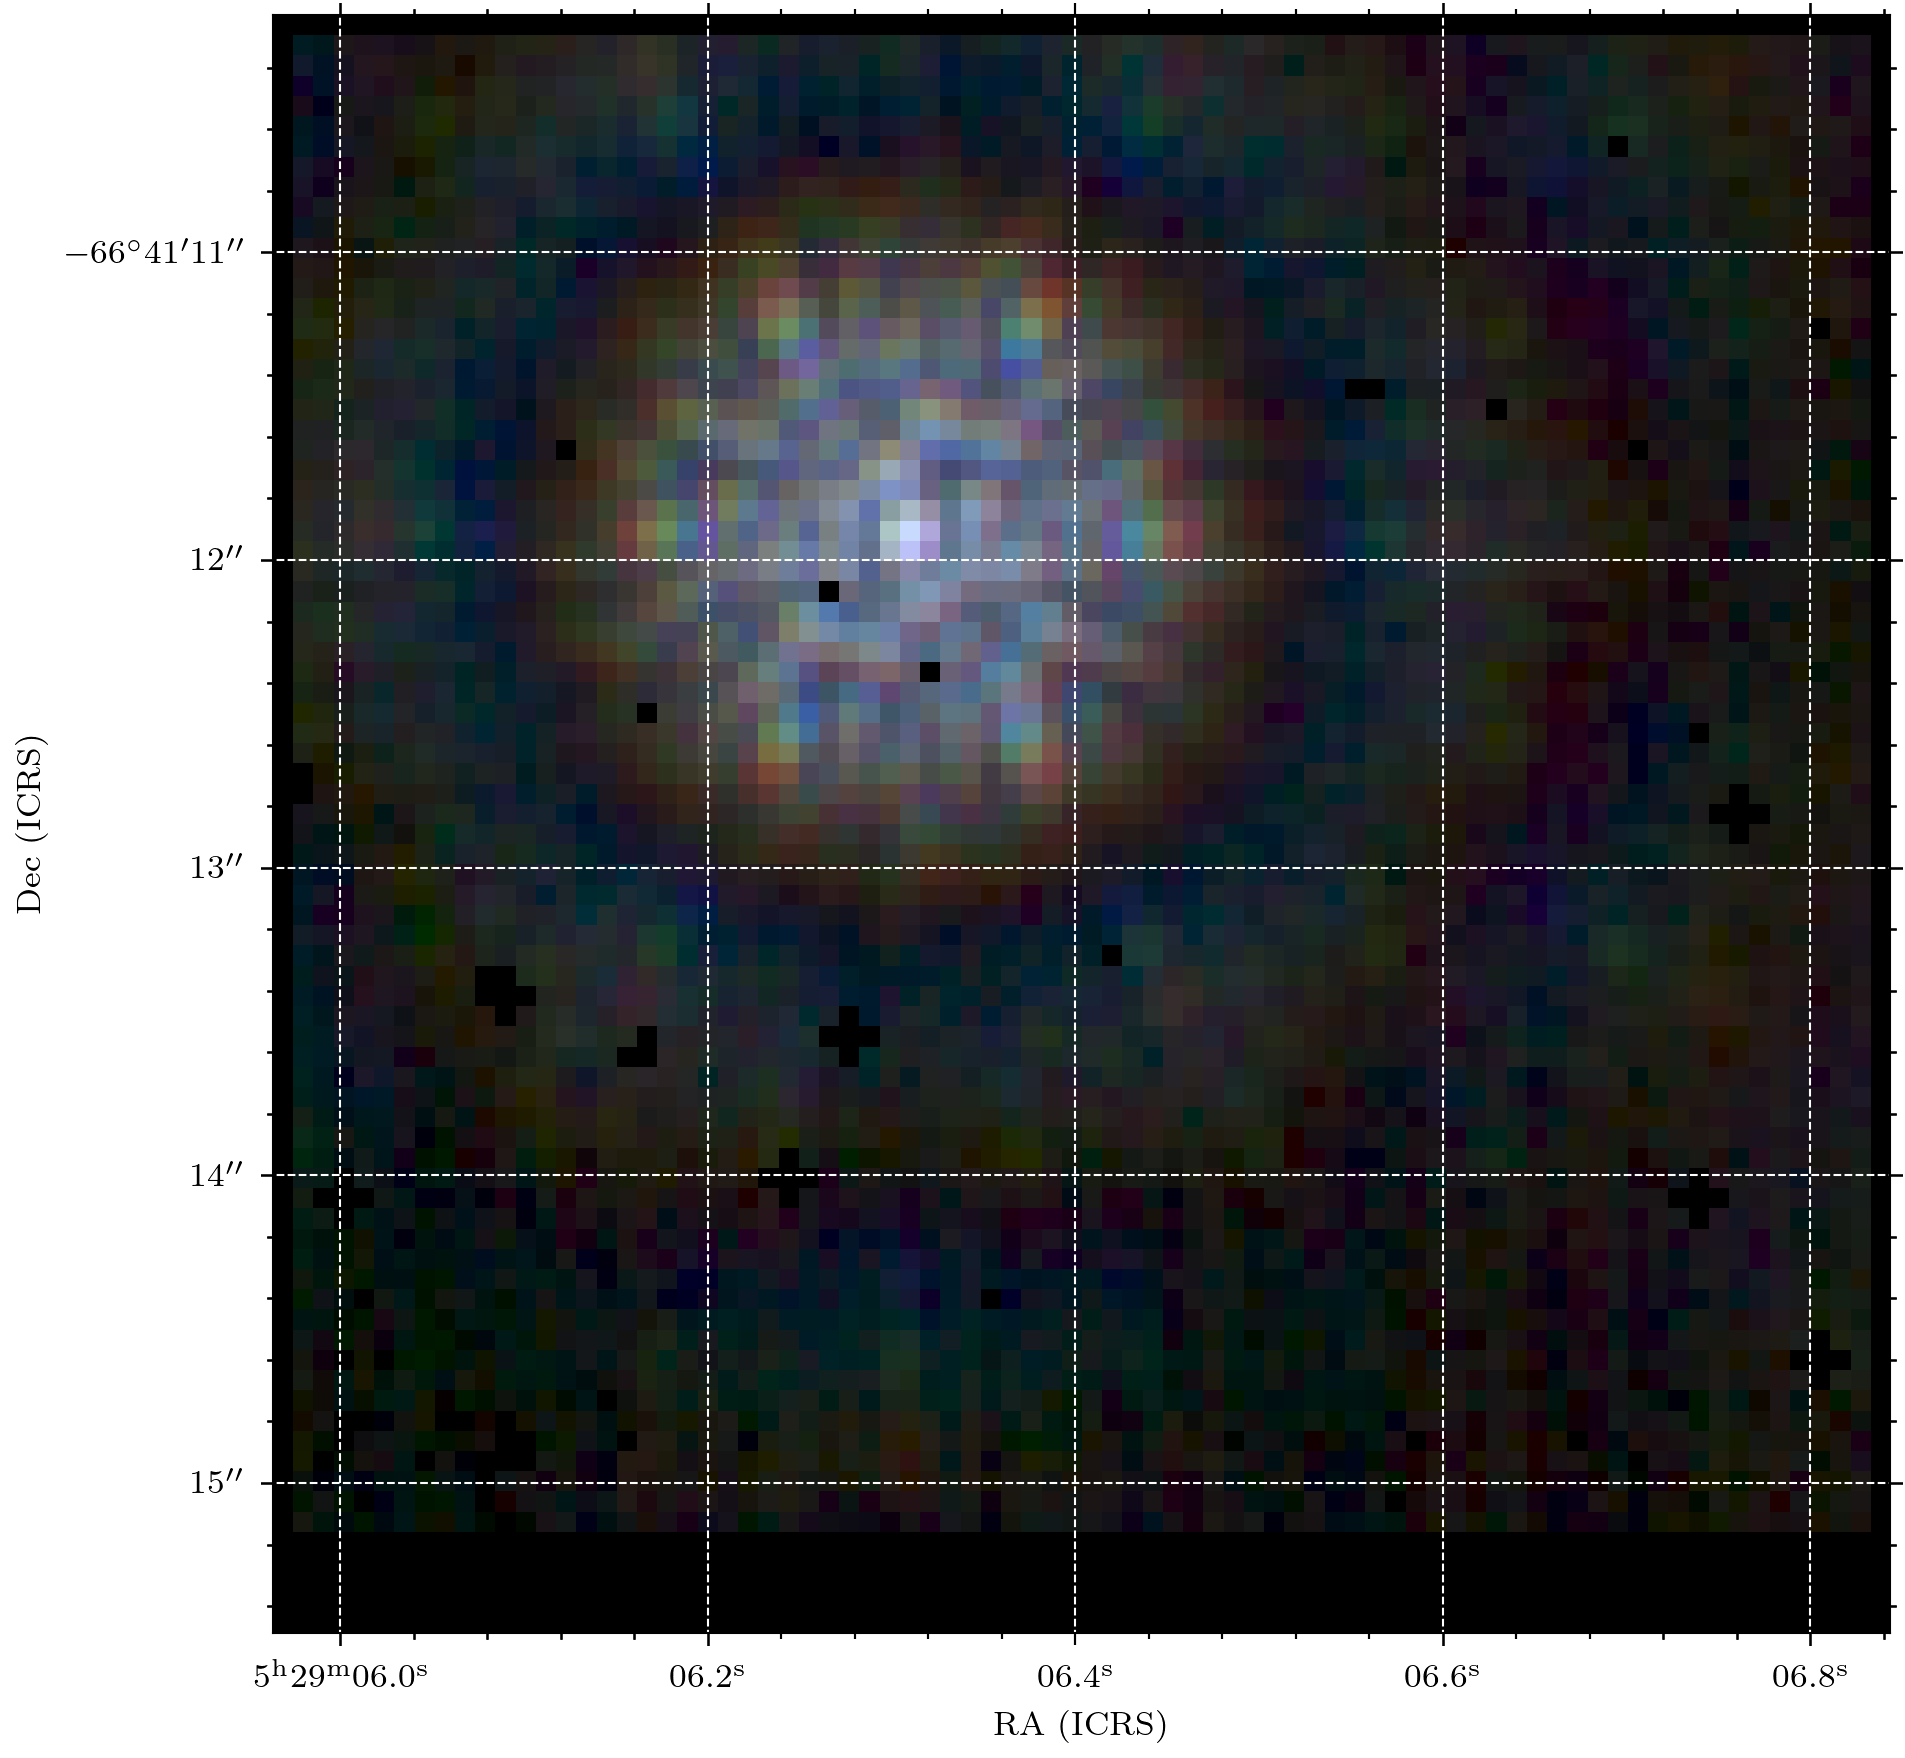

In [123]:
import matplotlib.pyplot as plt
from astropy.wcs import WCS
from astropy.io import fits
from astropy.coordinates import SkyCoord
import astropy.units as u

# --- Load image and WCS ---
wcs = w

# --- Define sky coordinates of the points to plot ---
# ra = [40]
# dec = [40]  # degrees

ra = [329.09166666]
dec = [-66.686388]  # degrees

sky_coords = SkyCoord(ra=ra * u.deg, dec=dec * u.deg, frame="icrs")

# --- Plot the image with WCS projection ---
fig = plt.figure(figsize=(8, 6))
ax = plt.subplot(111, projection=wcs)

# Plot the image
ax.imshow(abdor_rgb)

# # Overlay the points
# ax.scatter(
#     sky_coords.ra.deg,
#     sky_coords.dec.deg,
#     transform=ax.get_transform("icrs"),
#     s=50,
#     edgecolor="red",
#     facecolor="none",
#     label="My points",
# )

# Add labels/grid
ax.coords.grid(True, color="white", ls="--")
ax.set_xlabel("RA (ICRS)")
ax.set_ylabel("Dec (ICRS)")
ax.legend()
plt.tight_layout()
plt.show()